In [1]:
import numpy as np
import pandas as pd
from numba import njit
from datetime import timedelta
import talib
import vectorbt as vbt
from vectorbt.indicators.factory import IndicatorFactory

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

#My other files
from Data_Handling import *
from Alpaca_Credentials import ALPACA_API_KEY, ALPACA_SECRET_KEY
client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)


import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
from itertools import product
import optuna


In [2]:
# Configuration
symbol = "NVDA"
start_date = "2024-01-01"
end_date = "2025-05-20"
timeframe_unit = "Minute"
multiplier = 1

In [3]:
# 1. Load Data
data = get_data_auto(symbol, start=start_date, end=end_date, timeframe_unit=timeframe_unit, multiplier=multiplier)

optimization_window = 3
execution_window = 1

# NVIDIA EMA

In [4]:
ema_values = np.arange(2,120,2)
trailing_stop_values = np.arange(0.01, 0.1, 0.01)

In [21]:
#2. Define Strategy
@njit
def logic(close, ema):
    signals = np.where(close>ema,1,0)
    return np.where(close<ema,-1,signals)

def run_EMA_strat1(close, ema_val, trailing_stop_value):
    ema = vbt.IndicatorFactory.from_talib("EMA").run(close, int(ema_val)).real.to_numpy()
    return logic(close, ema), np.broadcast_to(trailing_stop_value, close.shape)

EMA_strat1 = IndicatorFactory(
    class_name="EMA1",
    short_name="ema1",
    input_names=["close"],
    param_names=["ema_val", "trailing_stop_value"],
    output_names=["signals","trailing_stop_values"] 
    ).from_apply_func(
        run_EMA_strat1
        )



In [22]:
#3. Walk-forward Loop
all_trades = []
all_pf=[]
dates = data.index.normalize().unique()

for i in range(optimization_window, len(dates) - execution_window):
    training_start = dates[i - optimization_window]
    training_end = dates[i - 1]
    test_start = dates[i]
    test_end = dates[i + execution_window]

    training_data = data.loc[training_start:training_end]
    test_data = data.loc[test_start:test_end]

    #3.1 Optimize on traning dates over parameters
    call_signals = EMA_strat1.run(
        close = training_data["Close"],
        ema_val = ema_values,
        trailing_stop_value = trailing_stop_values,
        param_product = True
        )

    pf_test = vbt.Portfolio.from_signals(
        close = training_data["Close"],
        entries = (call_signals.signals == 1.0),
        exits = (call_signals.signals == -1.0),
        size = 1,
        sl_stop = 0.01,
        sl_trail = call_signals.trailing_stop_values,
        freq = "m"
        )
    
    best_params, best_value, best_pf = Overfitting_reduction_simpler(pf_test, objective_function=None, smoothing_size=3, filter_threshold=0.0)

    #3.2 Run with optimised parameters
    optimum_signals = EMA_strat1.run(
        close = test_data["Close"],
        ema_val = best_params["ema1_ema_val"],
        trailing_stop_value = best_params["ema1_trailing_stop_value"],
        )
    pf_results = vbt.Portfolio.from_signals(
        close=test_data["Close"],
        entries = (optimum_signals.signals == 1.0),
        exits = (optimum_signals.signals == -1.0),
        size = 1,
        sl_trail = optimum_signals.trailing_stop_values,
        sl_stop = 0.01,    
        freq = "m"
        )

    #4 Record all trades
    trades_df = pf_results.trades.records[['entry_idx', 'exit_idx']].copy()

    offset = data.index.get_loc(test_data.index[0])
    trades_df['entry_idx'] += offset
    trades_df['exit_idx'] += offset
    all_trades.append(trades_df)

    #5 Record all pfs and deciision metrics
    all_pf.append({
        "Portfolios": pf_results,
        "Expected Returns": best_value,
        "params": best_params,
        "date": test_start
        })

In [23]:
all_trades_df = pd.concat(all_trades, ignore_index=True)
entries, exits = build_signals_from_trade_indices(all_trades_df, data.index)


final_pf = vbt.Portfolio.from_signals(
    close=data["Close"],
    entries=entries,
    exits=exits,
    size=1,
    sl_trail=0.01,
    freq="4h"
)

final_pf.plot()



FigureWidget({
    'data': [{'legendgroup': '0',
              'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': '2ddc244c-d6fc-491c-9768-e0de609a590e',
              'x': array([datetime.datetime(2024, 1, 2, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2024, 1, 2, 9, 1, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2024, 1, 2, 9, 2, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2025, 5, 19, 23, 57, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2025, 5, 19, 23, 58, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2025, 5, 19, 23, 59, tzinfo=TzInfo(UTC))],
                         dtype=object),
              'xaxis': 'x',
              'y': array([494.72, 494.83, 495.22, ..., 135.69, 135.7 , 135.67]),
              'yaxis': 'y'},
             {'customdata': array([[0.00000000e+00, 2.080

# NVIDIA RSI

In [9]:
entry_thresholds = np.arange(5,40,5)
exit_thresholds = np.arange (60,95,5)
rsi_periods = np.arange (7, 98, 7)

In [10]:
#2. Define Strategy
@njit
def logic(rsi_vals, entry_threshold, exit_threshold):
    signals = np.where(rsi_vals<entry_threshold,1,0)
    return np.where(rsi_vals>exit_threshold,-1,signals)

def run_RSI_strat1(close, entry_threshold, exit_threshold, rsi_period):
    rsi_vals = vbt.IndicatorFactory.from_talib("RSI").run(close, rsi_period).real.to_numpy()
    return logic(rsi_vals, entry_threshold, exit_threshold)

RSI_strat1 = IndicatorFactory(
    class_name="RSI1",
    short_name="rsi1",
    input_names=["close"],
    param_names=["entry_threshold","exit_threshold","rsi_period"],
    output_names=["signals"] 
    ).from_apply_func(
        run_RSI_strat1
        )



In [12]:
#3. Walk-forward Loop
all_trades = []
all_pf=[]
dates = data.index.normalize().unique()

for i in range(optimization_window, len(dates) - execution_window):
    training_start = dates[i - optimization_window]
    training_end = dates[i - 1]
    test_start = dates[i]
    test_end = dates[i + execution_window]

    training_data = data.loc[training_start:training_end]
    test_data = data.loc[test_start:test_end]

    #3.1 Optimize on traning dates over parameters
    call_signals = RSI_strat1.run(
        close=training_data["Close"],
        entry_threshold=entry_thresholds,
        exit_threshold=exit_thresholds,
        rsi_period=rsi_periods,
        param_product=True
    )

    pf_test = vbt.Portfolio.from_signals(
        close=training_data["Close"],
        entries=(call_signals.signals == 1.0),
        exits=(call_signals.signals == -1.0),
        size=1,
        sl_stop=0.05,
        tp_stop= 0.1,
        freq="4h"
    )

    best_params, best_value, best_pf = Overfitting_reduction_simpler(
        pf_test, objective_function=None, smoothing_size=5, filter_threshold=0.0)

    #3.2 Run with optimised parameters
    optimum_signals = RSI_strat1.run(
        close=test_data["Close"],
        entry_threshold=best_params["rsi1_entry_threshold"],
        exit_threshold=best_params["rsi1_exit_threshold"],
        rsi_period=best_params["rsi1_rsi_period"]
    )

    pf_results = vbt.Portfolio.from_signals(
        close=test_data["Close"],
        entries=(optimum_signals.signals == 1.0),
        exits=(optimum_signals.signals == -1.0),
        size=1,
        sl_stop=0.05,
        tp_stop= 0.1,
        freq="4h"
    )

    #4 Record all trades
    trades_df = pf_results.trades.records[['entry_idx', 'exit_idx']].copy()

    offset = data.index.get_loc(test_data.index[0])
    trades_df['entry_idx'] += offset
    trades_df['exit_idx'] += offset
    all_trades.append(trades_df)

    #5 Record all pfs and deciision metrics
    all_pf.append({
        "Portfolios": pf_results,
        "Expected Returns": best_value,
        "params": best_params,
        "date": test_start
        })


373
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


IndexError: index 376 is out of bounds for axis 0 with size 376

In [14]:
len(dates)

376

In [15]:
all_trades_df = pd.concat(all_trades, ignore_index=True)
entries, exits = build_signals_from_trade_indices(all_trades_df, data.index)


final_pf = vbt.Portfolio.from_signals(
    close=data["Close"],
    entries=entries,
    exits=exits,
    size=1,
    sl_trail=0.01,
    freq="4h"
)

final_pf.plot()



FigureWidget({
    'data': [{'legendgroup': '0',
              'line': {'color': '#1f77b4'},
              'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': '5e965032-9304-43be-8742-e232d92fabf0',
              'x': array([datetime.datetime(2024, 1, 2, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2024, 1, 2, 9, 1, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2024, 1, 2, 9, 2, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2025, 5, 19, 23, 57, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2025, 5, 19, 23, 58, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2025, 5, 19, 23, 59, tzinfo=TzInfo(UTC))],
                         dtype=object),
              'xaxis': 'x',
              'y': array([494.72, 494.83, 495.22, ..., 135.69, 135.7 , 135.67]),
              'yaxis': 'y'},
             {'customdata': array([[0.00000000e+00, 2.033

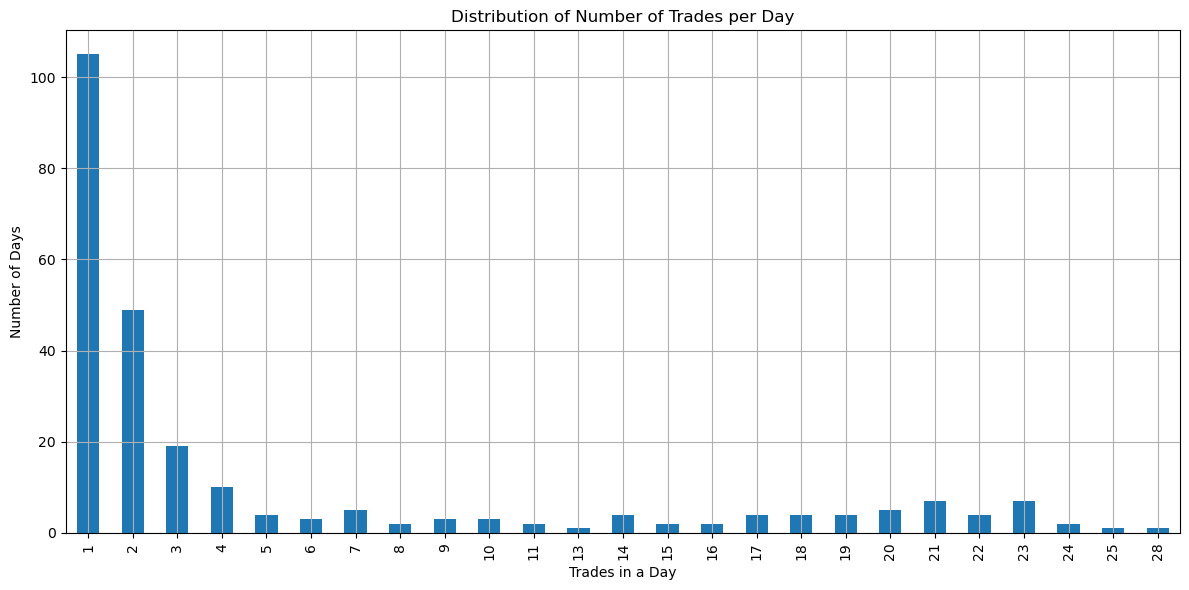

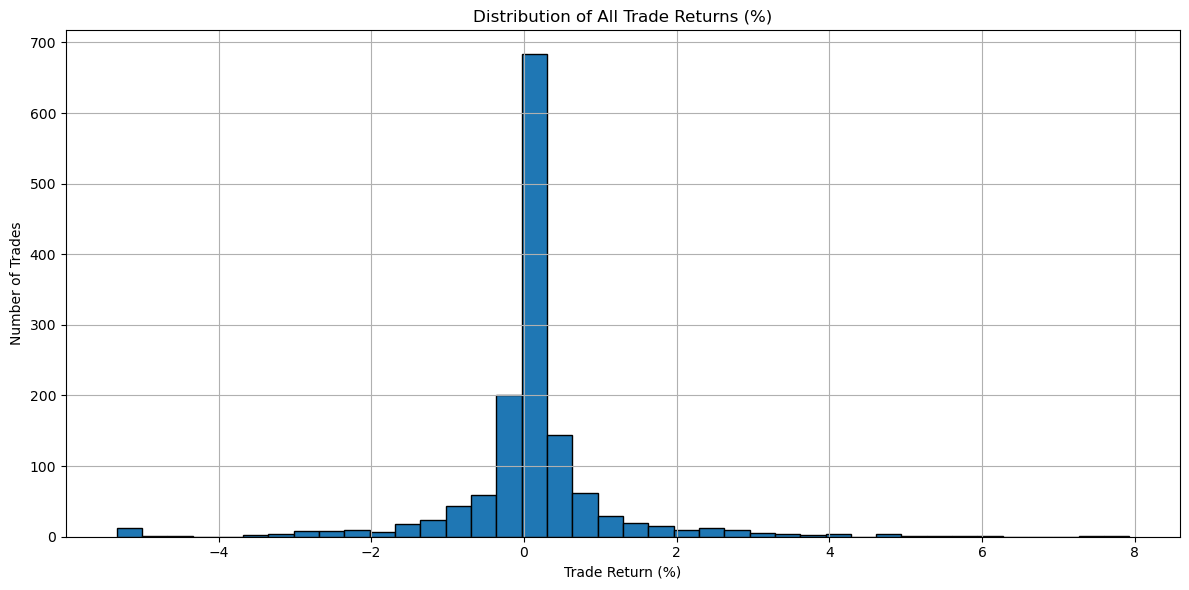

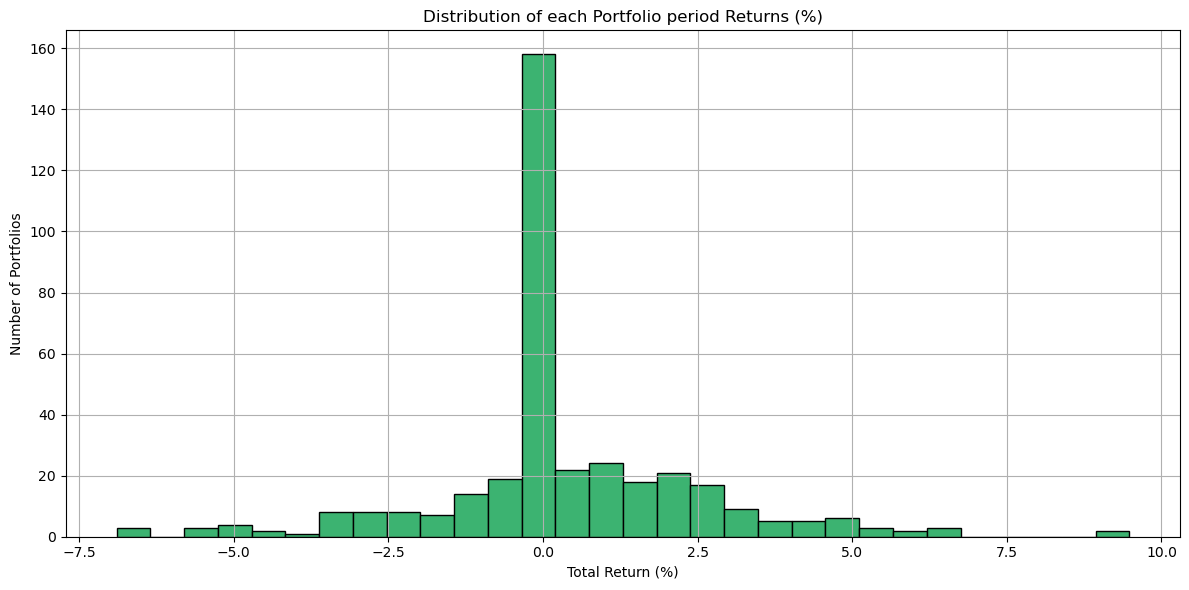

In [16]:

plot_trade_frequency_distribution_per_day(all_trades, data)
plot_trade_return_distribution_from_pf(final_pf)
plot_portfolios_return_distribution(all_pf)

In [18]:
# Lets look at the dates of those very negative vals 
# Idea is if they are consecutive or show patterns we can look at how to reduce them
bad_indices = [i for i, entry in enumerate(all_pf) if entry["Portfolios"].total_return() <= -0.009]

for i in bad_indices:
    print(f"Index: {i}, Date: {all_pf[i]['date']}, Return: {all_pf[i]['Portfolios'].total_return():.2%}")


Index: 9, Date: 2024-01-17 00:00:00+00:00, Return: -1.74%
Index: 26, Date: 2024-02-06 00:00:00+00:00, Return: -4.16%
Index: 31, Date: 2024-02-12 00:00:00+00:00, Return: -1.06%
Index: 40, Date: 2024-02-23 00:00:00+00:00, Return: -2.17%
Index: 57, Date: 2024-03-14 00:00:00+00:00, Return: -3.43%
Index: 65, Date: 2024-03-26 00:00:00+00:00, Return: -3.17%
Index: 66, Date: 2024-03-27 00:00:00+00:00, Return: -3.21%
Index: 71, Date: 2024-04-04 00:00:00+00:00, Return: -1.69%
Index: 78, Date: 2024-04-15 00:00:00+00:00, Return: -3.16%
Index: 82, Date: 2024-04-19 00:00:00+00:00, Return: -6.75%
Index: 89, Date: 2024-04-30 00:00:00+00:00, Return: -2.22%
Index: 96, Date: 2024-05-09 00:00:00+00:00, Return: -1.18%
Index: 102, Date: 2024-05-17 00:00:00+00:00, Return: -1.03%
Index: 104, Date: 2024-05-21 00:00:00+00:00, Return: -0.91%
Index: 110, Date: 2024-05-30 00:00:00+00:00, Return: -3.30%
Index: 115, Date: 2024-06-06 00:00:00+00:00, Return: -2.73%
Index: 124, Date: 2024-06-20 00:00:00+00:00, Return: 

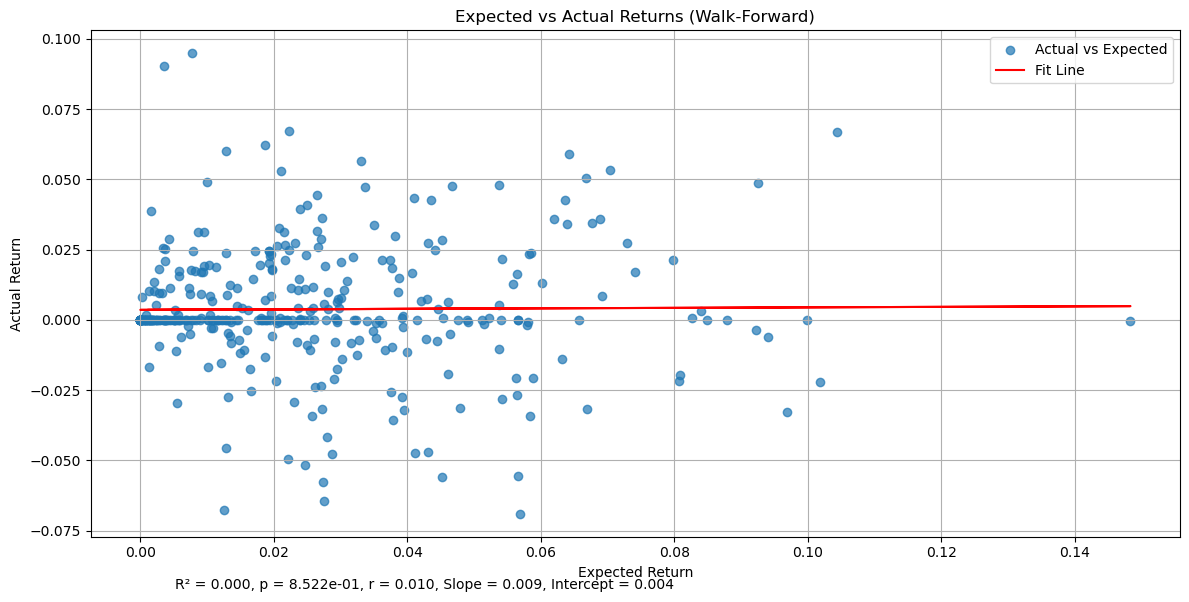

In [17]:
plot_expected_vs_actual_returns(all_pf)